In [1]:
#@title # Model #5: 1D (AAC/CTD features) + XGBoost
# =============================================================================
# Part of the InterPET ablation table:
#   1. 1D, ESM-2, XGBoost   (already done)
#   2. 1D, ESM-2, RF        (already done)
#   3. 1D, ProtT5, XGBoost  (already done)
#   4. 1D, ProtT5, RF       (already done)
#   5. 1D, AAC/CTD, XGBoost <- this notebook
#   6. 1D, AAC/CTD, RF
#   7. 1D, Graph (chain edges), GraphSAGE
#   8. 1D+3D, Graph (structure contact-map edges), GraphSAGE
#
# Model #5 swaps the input representation entirely: instead of a protein
# language model embedding (ESM-2/ProtT5), it uses classical handcrafted
# sequence features -- AAC (Amino Acid Composition) and CTD (Composition /
# Transition / Distribution of physicochemical property groups, Dubchak et
# al.). No GPU or protein language model is needed for this notebook.
#
# IMPORTANT DIFFERENCE vs. Model #1-4: AAC/CTD features are, by
# construction, human-interpretable (e.g. "% of charged residues", "% of
# buried hydrophobic residues"), unlike embedding dimensions from ESM-2/
# ProtT5. This means the SHAP analysis in this notebook is not just a model
# diagnostic -- it directly answers biological questions about which
# physicochemical properties drive the prediction. The mutagenesis scan is
# still included for direct comparison with Model #1-4 and because it adds
# POSITION-level resolution that aggregate composition features cannot
# provide on their own.
#
# All other methodology (CV, threshold from OOF, single-shot benchmark
# evaluation, metrics) is kept identical to Model #1/#3 (XGBoost classifier)
# so results remain comparable across the ablation table.


In [2]:
#@title # Mount Google Drive & Install dependencies
from google.colab import drive
drive.mount('/content/drive')

# No protein language model or GPU needed for this notebook -- AAC/CTD
# features are computed directly from the amino acid sequence.
!pip install -q xgboost scikit-learn pandas numpy shap tqdm seaborn


MessageError: Error: credential propagation was unsuccessful

In [ ]:
#@title # 1. Configuration

import os
import numpy as np
import pandas as pd
import pickle
from collections import Counter

PROJECT_ROOT = "/content/drive/MyDrive/InterPET"
DATASETS_DIR = os.path.join(PROJECT_ROOT, "datasets")
MODEL_OUT_DIR = os.path.join(PROJECT_ROOT, "models", "model5_aac_ctd_xgb")
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

TRAIN_FINAL_CSV = os.path.join(DATASETS_DIR, "train_final_labels.csv")
BENCHMARK_FINAL_CSV = os.path.join(DATASETS_DIR, "benchmark_final_labels.csv")

N_FOLDS = 5
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

for path in [TRAIN_FINAL_CSV, BENCHMARK_FINAL_CSV]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found. Run the Dataset Curation & QC notebook first.")


In [ ]:
#@title # 2. Load curated dataset

df_train = pd.read_csv(TRAIN_FINAL_CSV)
df_bench = pd.read_csv(BENCHMARK_FINAL_CSV)

print(f"Train: {len(df_train)} sequences ({df_train['label'].sum()} positive, {(df_train['label']==0).sum()} negative)")
print(f"Benchmark: {len(df_bench)} sequences ({df_bench['label'].sum()} positive, {(df_bench['label']==0).sum()} negative)")


In [ ]:
#@title # Resume from checkpoint (skip AAC/CTD feature extraction)
# Run this INSTEAD of sections 3-6 (AAC/CTD feature extraction, hyperparameter search,
# threshold optimization, final model training) if those already ran once
# before and you only want to redo visualization/interpretability (section 7
# onward) -- e.g. after a runtime restart, or when just tweaking plotting/
# analysis code. The "Mount Google Drive & Install dependencies" cell,
# section 1 (config), and section 2 (load dataset, for df_train/df_bench)
# still need to run first.

import json
import pickle
from collections import Counter
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score, average_precision_score,
    confusion_matrix, accuracy_score, matthews_corrcoef,
)
import xgboost as xgb

X_train_full = np.load(os.path.join(MODEL_OUT_DIR, "X_train_aac_ctd.npy"))
X_bench = np.load(os.path.join(MODEL_OUT_DIR, "X_bench_aac_ctd.npy"))
y_train_full = df_train["label"].astype(int).to_numpy()
y_bench = df_bench["label"].astype(int).to_numpy()

# Needed by section 11 (per-fold metrics), which re-instantiates an
# XGBClassifier with this same imbalance-handling weight.
n_pos = y_train_full.sum()
n_neg = len(y_train_full) - n_pos
scale_pos_weight = n_neg / n_pos

with open(os.path.join(MODEL_OUT_DIR, "feature_names.pkl"), "rb") as f:
    FEATURE_NAMES = pickle.load(f)

with open(os.path.join(MODEL_OUT_DIR, "best_params.json")) as f:
    best_params = json.load(f)

with open(os.path.join(MODEL_OUT_DIR, "chosen_threshold.txt")) as f:
    best_threshold = float(f.read())

with open(os.path.join(MODEL_OUT_DIR, "final_model.pkl"), "rb") as f:
    final_model = pickle.load(f)

oof_proba = np.load(os.path.join(MODEL_OUT_DIR, "oof_proba.npy"))
y_bench_proba = np.load(os.path.join(MODEL_OUT_DIR, "y_bench_proba.npy"))
y_bench_pred = np.load(os.path.join(MODEL_OUT_DIR, "y_bench_pred.npy"))

bench_metrics = pd.read_csv(
    os.path.join(MODEL_OUT_DIR, "benchmark_metrics.csv"), index_col=0
).squeeze("columns").to_dict()

# Re-create the CV splitter (deterministic given the same random_state, so
# this reproduces the exact same folds without retraining anything).
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Cheap to recompute from oof_proba (no retraining involved) -- needed for
# the "F1 vs threshold" plot in section 10.
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_train_full, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
oof_pred = (oof_proba >= best_threshold).astype(int)

# Needed later for the mutagenesis sections -- AAC/CTD feature computation
# is pure Python (no model to reload), so we just redefine the feature
# functions here (identical to section 3).
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

AA_GROUPS = {
    "Hydrophobicity":          {1: "RKEDQN",           2: "GASTPHY",           3: "CLVIMFW"},
    "NormVanDerWaalsVolume":   {1: "GASTPDC",           2: "NVEQIL",            3: "MHKFRYW"},
    "Polarity":                {1: "LIFWCMVY",          2: "PATGS",             3: "HQRKNED"},
    "Polarizability":          {1: "GASDT",             2: "CPNVEQIL",          3: "KMHFRYW"},
    "Charge":                  {1: "KR",                2: "ANCQGHILMFPSTWYV",  3: "DE"},
    "SecondaryStructure":      {1: "EALMQKRH",          2: "VIYCWFT",           3: "GNPSD"},
    "SolventAccessibility":    {1: "ALFCGIVW",          2: "RKQEND",            3: "MPSTHY"},
}


def clean_sequence(seq):
    seq = seq.strip().upper()
    return "".join(c for c in seq if c in AMINO_ACIDS)


def compute_aac(seq):
    seq = clean_sequence(seq)
    n = len(seq)
    counts = Counter(seq)
    return {f"AAC_{aa}": (counts.get(aa, 0) / n if n else 0.0) for aa in AMINO_ACIDS}


def _group_sequence(seq, groups):
    mapping = {aa: g for g, aas in groups.items() for aa in aas}
    return [mapping[aa] for aa in seq if aa in mapping]


def get_ctd_feature_names():
    names = []
    for prop in AA_GROUPS:
        names += [f"{prop}_C{g}" for g in (1, 2, 3)]
        names += [f"{prop}_T12", f"{prop}_T13", f"{prop}_T23"]
        for g in (1, 2, 3):
            names += [f"{prop}_group{g}_{label}" for label in ("D0", "D25", "D50", "D75", "D100")]
    return names


CTD_FEATURE_NAMES = get_ctd_feature_names()


def compute_ctd(seq):
    seq = clean_sequence(seq)
    L = len(seq)
    if L == 0:
        return {name: 0.0 for name in CTD_FEATURE_NAMES}

    features = {}
    for prop, groups in AA_GROUPS.items():
        gseq = _group_sequence(seq, groups)
        gL = len(gseq)

        for g in (1, 2, 3):
            features[f"{prop}_C{g}"] = (gseq.count(g) / gL) if gL else 0.0

        trans_counts = {(1, 2): 0, (1, 3): 0, (2, 3): 0}
        for i in range(gL - 1):
            pair = tuple(sorted((gseq[i], gseq[i + 1])))
            if pair[0] != pair[1] and pair in trans_counts:
                trans_counts[pair] += 1
        denom = (gL - 1) if gL > 1 else 1
        features[f"{prop}_T12"] = trans_counts[(1, 2)] / denom
        features[f"{prop}_T13"] = trans_counts[(1, 3)] / denom
        features[f"{prop}_T23"] = trans_counts[(2, 3)] / denom

        for g in (1, 2, 3):
            positions = [i for i, x in enumerate(gseq) if x == g]
            n_g = len(positions)
            for pct, label in zip((0, 25, 50, 75, 100), ("D0", "D25", "D50", "D75", "D100")):
                if n_g == 0:
                    features[f"{prop}_group{g}_{label}"] = 0.0
                else:
                    idx = min(max(0, int(np.ceil(pct / 100 * n_g)) - 1), n_g - 1)
                    features[f"{prop}_group{g}_{label}"] = (positions[idx] + 1) / gL * 100

    return features


def compute_features(seq):
    feats = {}
    feats.update(compute_aac(seq))
    feats.update(compute_ctd(seq))
    return np.array([feats[name] for name in FEATURE_NAMES], dtype=float)


def get_features_batch(sequences):
    return np.vstack([compute_features(s) for s in sequences])

print("Checkpoint loaded -- ready to jump to section 7 (visualization & interpretability).")
print(f"X_train_full: {X_train_full.shape}, X_bench: {X_bench.shape}")
print(f"best_params: {best_params}")
print(f"best_threshold: {best_threshold:.2f}")
print("Benchmark metrics:", bench_metrics)


In [ ]:
#@title # 3. Extract AAC/CTD features (handcrafted, no GPU required)

# AAC: Amino Acid Composition -- fraction of each of the 20 standard amino
# acids in the sequence (20 features).
#
# CTD: Composition / Transition / Distribution of 7 physicochemical
# property groups (Dubchak et al. 1995/1999), each amino acid classified
# into 1 of 3 groups per property:
#   - Composition (C): % of residues in each group (3 features/property)
#   - Transition   (T): % of adjacent-residue transitions between groups
#                       (3 features/property)
#   - Distribution (D): sequence position (as % of length) at which the
#                       1st/25%/50%/75%/100% of a group's residues occur
#                       (5 features/group x 3 groups = 15 features/property)
# -> 21 features/property x 7 properties = 147 CTD features
# Total feature vector: 20 (AAC) + 147 (CTD) = 167 features, all with
# biologically meaningful names (unlike opaque embedding dimensions).

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

AA_GROUPS = {
    "Hydrophobicity":          {1: "RKEDQN",           2: "GASTPHY",           3: "CLVIMFW"},
    "NormVanDerWaalsVolume":   {1: "GASTPDC",           2: "NVEQIL",            3: "MHKFRYW"},
    "Polarity":                {1: "LIFWCMVY",          2: "PATGS",             3: "HQRKNED"},
    "Polarizability":          {1: "GASDT",             2: "CPNVEQIL",          3: "KMHFRYW"},
    "Charge":                  {1: "KR",                2: "ANCQGHILMFPSTWYV",  3: "DE"},
    "SecondaryStructure":      {1: "EALMQKRH",          2: "VIYCWFT",           3: "GNPSD"},
    "SolventAccessibility":    {1: "ALFCGIVW",          2: "RKQEND",            3: "MPSTHY"},
}


def clean_sequence(seq):
    seq = seq.strip().upper()
    return "".join(c for c in seq if c in AMINO_ACIDS)


def compute_aac(seq):
    seq = clean_sequence(seq)
    n = len(seq)
    counts = Counter(seq)
    return {f"AAC_{aa}": (counts.get(aa, 0) / n if n else 0.0) for aa in AMINO_ACIDS}


def _group_sequence(seq, groups):
    mapping = {aa: g for g, aas in groups.items() for aa in aas}
    return [mapping[aa] for aa in seq if aa in mapping]


def get_ctd_feature_names():
    names = []
    for prop in AA_GROUPS:
        names += [f"{prop}_C{g}" for g in (1, 2, 3)]
        names += [f"{prop}_T12", f"{prop}_T13", f"{prop}_T23"]
        for g in (1, 2, 3):
            names += [f"{prop}_group{g}_{label}" for label in ("D0", "D25", "D50", "D75", "D100")]
    return names


CTD_FEATURE_NAMES = get_ctd_feature_names()


def compute_ctd(seq):
    seq = clean_sequence(seq)
    L = len(seq)
    if L == 0:
        return {name: 0.0 for name in CTD_FEATURE_NAMES}

    features = {}
    for prop, groups in AA_GROUPS.items():
        gseq = _group_sequence(seq, groups)
        gL = len(gseq)

        for g in (1, 2, 3):
            features[f"{prop}_C{g}"] = (gseq.count(g) / gL) if gL else 0.0

        trans_counts = {(1, 2): 0, (1, 3): 0, (2, 3): 0}
        for i in range(gL - 1):
            pair = tuple(sorted((gseq[i], gseq[i + 1])))
            if pair[0] != pair[1] and pair in trans_counts:
                trans_counts[pair] += 1
        denom = (gL - 1) if gL > 1 else 1
        features[f"{prop}_T12"] = trans_counts[(1, 2)] / denom
        features[f"{prop}_T13"] = trans_counts[(1, 3)] / denom
        features[f"{prop}_T23"] = trans_counts[(2, 3)] / denom

        for g in (1, 2, 3):
            positions = [i for i, x in enumerate(gseq) if x == g]
            n_g = len(positions)
            for pct, label in zip((0, 25, 50, 75, 100), ("D0", "D25", "D50", "D75", "D100")):
                if n_g == 0:
                    features[f"{prop}_group{g}_{label}"] = 0.0
                else:
                    idx = min(max(0, int(np.ceil(pct / 100 * n_g)) - 1), n_g - 1)
                    features[f"{prop}_group{g}_{label}"] = (positions[idx] + 1) / gL * 100

    return features


FEATURE_NAMES = [f"AAC_{aa}" for aa in AMINO_ACIDS] + CTD_FEATURE_NAMES


def compute_features(seq):
    feats = {}
    feats.update(compute_aac(seq))
    feats.update(compute_ctd(seq))
    return np.array([feats[name] for name in FEATURE_NAMES], dtype=float)


def get_features_batch(sequences):
    return np.vstack([compute_features(s) for s in sequences])


print(f"Total AAC/CTD features: {len(FEATURE_NAMES)} (20 AAC + {len(CTD_FEATURE_NAMES)} CTD)")

print("\nComputing training set features...")
X_train_full = get_features_batch(df_train["sequence"].tolist())
y_train_full = df_train["label"].astype(int).to_numpy()
print(f"Shape: {X_train_full.shape}")

print("\nComputing benchmark set features...")
X_bench = get_features_batch(df_bench["sequence"].tolist())
y_bench = df_bench["label"].astype(int).to_numpy()
print(f"Shape: {X_bench.shape}")

np.save(os.path.join(MODEL_OUT_DIR, "X_train_aac_ctd.npy"), X_train_full)
np.save(os.path.join(MODEL_OUT_DIR, "X_bench_aac_ctd.npy"), X_bench)
with open(os.path.join(MODEL_OUT_DIR, "feature_names.pkl"), "wb") as f:
    pickle.dump(FEATURE_NAMES, f)


Total AAC/CTD features: 167 (20 AAC + 147 CTD)

Computing training set features...
Shape: (937, 167)

Computing benchmark set features...
Shape: (139, 167)


In [ ]:
#@title # 4. Hyperparameter search (Stratified K-Fold CV)

import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

# Same param grid and CV protocol as Model #1/#3 -- only the input
# representation (AAC/CTD instead of a protein language model embedding)
# changes.
param_grid = [
    {"max_depth": 4, "learning_rate": 0.05, "n_estimators": 300, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 6, "learning_rate": 0.05, "n_estimators": 300, "subsample": 0.8, "colsample_bytree": 0.8},
    {"max_depth": 4, "learning_rate": 0.1, "n_estimators": 200, "subsample": 0.9, "colsample_bytree": 0.9},
    {"max_depth": 6, "learning_rate": 0.1, "n_estimators": 200, "subsample": 0.9, "colsample_bytree": 0.9},
    {"max_depth": 8, "learning_rate": 0.03, "n_estimators": 400, "subsample": 0.7, "colsample_bytree": 0.7},
]

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

n_pos = y_train_full.sum()
n_neg = len(y_train_full) - n_pos
scale_pos_weight = n_neg / n_pos
print(f"scale_pos_weight (imbalance handling): {scale_pos_weight:.2f}")

best_params, best_cv_f1 = None, -1
cv_results_log = []

for params in param_grid:
    fold_f1s = []
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_train_full, y_train_full)):
        model = xgb.XGBClassifier(
            **params, scale_pos_weight=scale_pos_weight, eval_metric="logloss",
            random_state=RANDOM_SEED, use_label_encoder=False,
        )
        model.fit(X_train_full[tr_idx], y_train_full[tr_idx])
        proba = model.predict_proba(X_train_full[va_idx])[:, 1]
        pred = (proba >= 0.5).astype(int)
        fold_f1s.append(f1_score(y_train_full[va_idx], pred, zero_division=0))

    mean_f1 = np.mean(fold_f1s)
    cv_results_log.append({**params, "cv_f1_mean": mean_f1, "cv_f1_std": np.std(fold_f1s)})
    print(f"  params={params} -> CV F1 = {mean_f1:.4f} (+/- {np.std(fold_f1s):.4f})")

    if mean_f1 > best_cv_f1:
        best_cv_f1 = mean_f1
        best_params = params

print(f"\nBest params: {best_params}")
print(f"Best CV F1: {best_cv_f1:.4f}")

pd.DataFrame(cv_results_log).to_csv(os.path.join(MODEL_OUT_DIR, "cv_hyperparam_search.csv"), index=False)

import json
with open(os.path.join(MODEL_OUT_DIR, "best_params.json"), "w") as f:
    json.dump(best_params, f)


scale_pos_weight (imbalance handling): 1.33


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:32:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:32:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:32:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  params={'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.8, 'colsample_bytree': 0.8} -> CV F1 = 0.9197 (+/- 0.0400)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  params={'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.8, 'colsample_bytree': 0.8} -> CV F1 = 0.9210 (+/- 0.0400)


...

  params={'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.9, 'colsample_bytree': 0.9} -> CV F1 = 0.9180 (+/- 0.0372)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  params={'max_depth': 6, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.9, 'colsample_bytree': 0.9} -> CV F1 = 0.9207 (+/- 0.0369)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

  params={'max_depth': 8, 'learning_rate': 0.03, 'n_estimators': 400, 'subsample': 0.7, 'colsample_bytree': 0.7} -> CV F1 = 0.9208 (+/- 0.0400)

Best params: {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best CV F1: 0.9210


In [ ]:
#@title # 5. Threshold optimization via OUT-OF-FOLD predictions (not from the benchmark!)

# Same as Model #1-4: the threshold is chosen from out-of-fold (OOF)
# predictions, NOT peeked from the benchmark, to avoid data leakage.

oof_proba = np.zeros(len(y_train_full))

for tr_idx, va_idx in skf.split(X_train_full, y_train_full):
    model = xgb.XGBClassifier(
        **best_params, scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=RANDOM_SEED, use_label_encoder=False,
    )
    model.fit(X_train_full[tr_idx], y_train_full[tr_idx])
    oof_proba[va_idx] = model.predict_proba(X_train_full[va_idx])[:, 1]

thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores = [f1_score(y_train_full, (oof_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"OOF F1 across thresholds -- best: {best_threshold:.2f} (F1={max(f1_scores):.4f})")
print("\nDetailed OOF metrics at the best threshold:")
oof_pred = (oof_proba >= best_threshold).astype(int)
print(f"  F1        : {f1_score(y_train_full, oof_pred):.4f}")
print(f"  Precision : {precision_score(y_train_full, oof_pred):.4f}")
print(f"  Recall    : {recall_score(y_train_full, oof_pred):.4f}")
print(f"  AUC       : {roc_auc_score(y_train_full, oof_proba):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_train_full, oof_proba):.4f}")

with open(os.path.join(MODEL_OUT_DIR, "chosen_threshold.txt"), "w") as f:
    f.write(str(best_threshold))

np.save(os.path.join(MODEL_OUT_DIR, "oof_proba.npy"), oof_proba)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

OOF F1 across thresholds -- best: 0.57 (F1=0.9227)

Detailed OOF metrics at the best threshold:
  F1        : 0.9227
  Precision : 0.9778
  Recall    : 0.8734
  AUC       : 0.9578
  PR-AUC    : 0.9618


In [ ]:
#@title # 6. Train final model (full training set) & evaluate ONCE on the benchmark

final_model = xgb.XGBClassifier(
    **best_params, scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    random_state=RANDOM_SEED, use_label_encoder=False,
)
final_model.fit(X_train_full, y_train_full)

y_bench_proba = final_model.predict_proba(X_bench)[:, 1]
y_bench_pred = (y_bench_proba >= best_threshold).astype(int)

from sklearn.metrics import confusion_matrix, accuracy_score, matthews_corrcoef

bench_metrics = {
    "accuracy": accuracy_score(y_bench, y_bench_pred),
    "precision": precision_score(y_bench, y_bench_pred, zero_division=0),
    "recall": recall_score(y_bench, y_bench_pred, zero_division=0),
    "f1": f1_score(y_bench, y_bench_pred, zero_division=0),
    "auc": roc_auc_score(y_bench, y_bench_proba),
    "pr_auc": average_precision_score(y_bench, y_bench_proba),
    "mcc": matthews_corrcoef(y_bench, y_bench_pred),
}

print("=" * 60)
print("MODEL #5: 1D + AAC/CTD + XGBoost -- BENCHMARK RESULTS")
print(f"(threshold={best_threshold:.2f}, chosen from OOF -- not from the benchmark)")
print("=" * 60)
for k, v in bench_metrics.items():
    print(f"  {k:<10}: {v:.4f}")

cm = confusion_matrix(y_bench, y_bench_pred)
print(f"\nConfusion Matrix:")
print(f"  TP: {cm[1,1]}, FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}, TN: {cm[0,0]}")

pd.Series(bench_metrics).to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics.csv"))

with open(os.path.join(MODEL_OUT_DIR, "final_model.pkl"), "wb") as f:
    pickle.dump(final_model, f)
np.save(os.path.join(MODEL_OUT_DIR, "y_bench_proba.npy"), y_bench_proba)
np.save(os.path.join(MODEL_OUT_DIR, "y_bench_pred.npy"), y_bench_pred)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:33:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MODEL #5: 1D + AAC/CTD + XGBoost -- BENCHMARK RESULTS
(threshold=0.57, chosen from OOF -- not from the benchmark)
  accuracy  : 0.9209
  precision : 0.7037
  recall    : 0.8636
  f1        : 0.7755
  auc       : 0.9658
  pr_auc    : 0.7741
  mcc       : 0.7337

Confusion Matrix:
  TP: 19, FP: 8
  FN: 3, TN: 109


In [6]:
#@title # 7. Additional imports for visualization & interpretability
!pip install -q seaborn shap

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
import shap
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score

sns.set_style("whitegrid")
n_pos = y_train_full.sum()
n_neg = len(y_train_full) - n_pos
scale_pos_weight = n_neg / n_pos


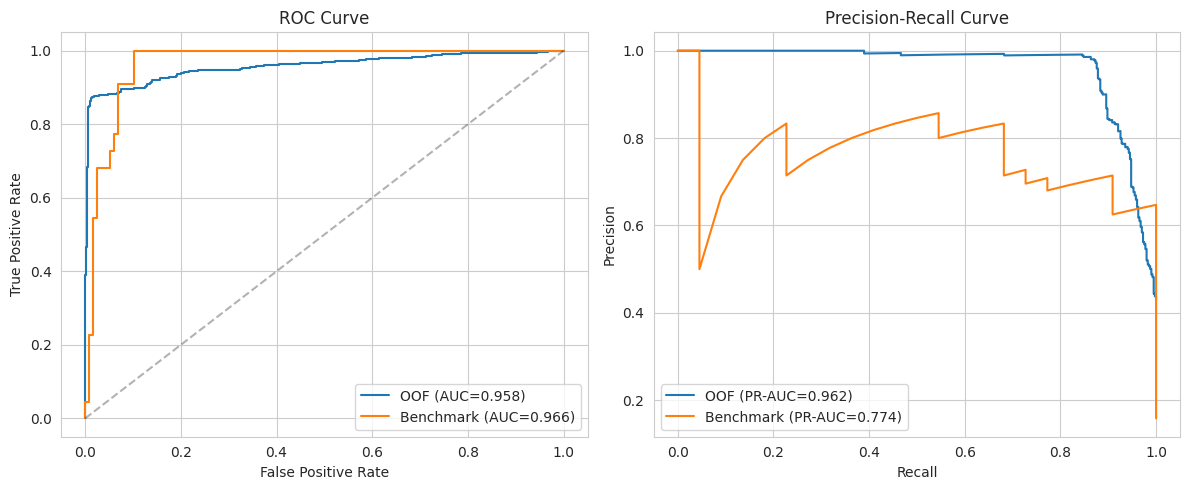

In [7]:
#@title # 8. ROC and Precision-Recall curves (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr_oof, tpr_oof, _ = roc_curve(y_train_full, oof_proba)
fpr_bench, tpr_bench, _ = roc_curve(y_bench, y_bench_proba)
axes[0].plot(fpr_oof, tpr_oof, label=f"OOF (AUC={roc_auc_score(y_train_full, oof_proba):.3f})")
axes[0].plot(fpr_bench, tpr_bench, label=f"Benchmark (AUC={bench_metrics['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

prec_oof, rec_oof, _ = precision_recall_curve(y_train_full, oof_proba)
prec_bench, rec_bench, _ = precision_recall_curve(y_bench, y_bench_proba)
axes[1].plot(rec_oof, prec_oof, label=f"OOF (PR-AUC={average_precision_score(y_train_full, oof_proba):.3f})")
axes[1].plot(rec_bench, prec_bench, label=f"Benchmark (PR-AUC={bench_metrics['pr_auc']:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "roc_pr_curves.png"), dpi=600)
plt.show()


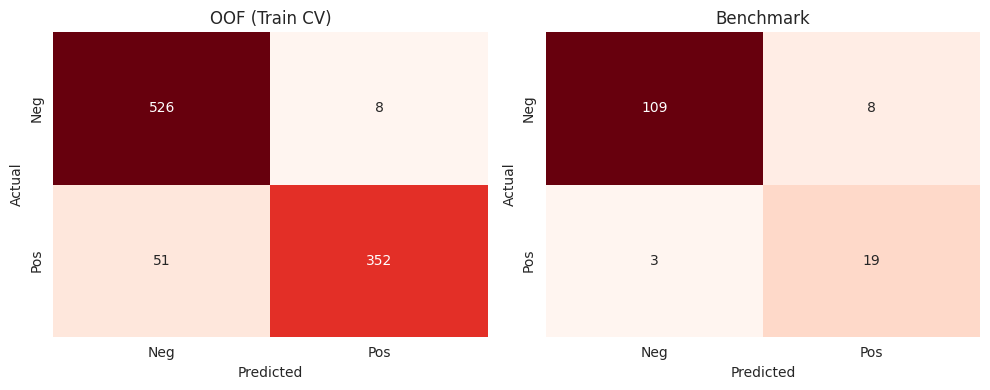

In [8]:
#@title # 9. Confusion matrix heatmaps (OOF vs Benchmark)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_oof = confusion_matrix(y_train_full, oof_pred)
cm_bench_ = confusion_matrix(y_bench, y_bench_pred)

for ax, cm, title in zip(axes, [cm_oof, cm_bench_], ["OOF (Train CV)", "Benchmark"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False,
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "confusion_matrices.png"), dpi=600)
plt.show()


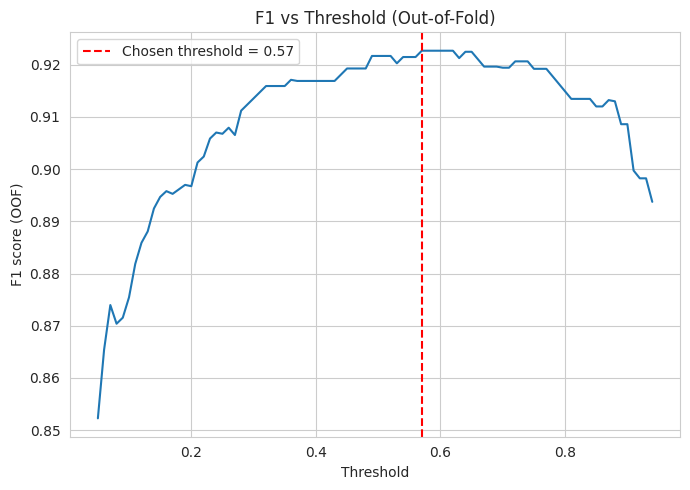

In [9]:
#@title # 10. F1 score vs threshold (OOF)
plt.figure(figsize=(7, 5))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--",
            label=f"Chosen threshold = {best_threshold:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 score (OOF)")
plt.title("F1 vs Threshold (Out-of-Fold)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "f1_vs_threshold.png"), dpi=600)
plt.show()


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:19:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:19:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:19:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:20:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

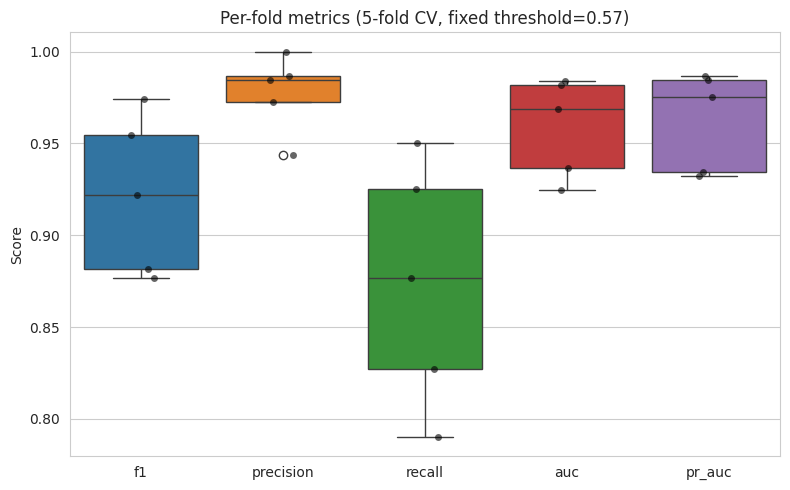

            f1  precision    recall       auc    pr_auc
mean  0.921913   0.977509  0.873765  0.959091  0.962578
std   0.043315   0.021271  0.066356  0.027173  0.026966


In [10]:
#@title # 11. Per-fold metrics with best hyperparameters (multi-metric)
# The hyperparameter search earlier only tracked F1 per fold. Here we
# re-run CV with the chosen best_params and best_threshold, this time
# recording every metric per fold so we can see variance across folds,
# not just the mean.

fold_metrics = {"f1": [], "precision": [], "recall": [], "auc": [], "pr_auc": []}

for tr_idx, va_idx in skf.split(X_train_full, y_train_full):
    model = xgb.XGBClassifier(
        **best_params, scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=RANDOM_SEED, use_label_encoder=False,
    )
    model.fit(X_train_full[tr_idx], y_train_full[tr_idx])
    proba = model.predict_proba(X_train_full[va_idx])[:, 1]
    pred = (proba >= best_threshold).astype(int)

    fold_metrics["f1"].append(f1_score(y_train_full[va_idx], pred, zero_division=0))
    fold_metrics["precision"].append(precision_score(y_train_full[va_idx], pred, zero_division=0))
    fold_metrics["recall"].append(recall_score(y_train_full[va_idx], pred, zero_division=0))
    fold_metrics["auc"].append(roc_auc_score(y_train_full[va_idx], proba))
    fold_metrics["pr_auc"].append(average_precision_score(y_train_full[va_idx], proba))

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df.to_csv(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics.csv"), index=False)

plt.figure(figsize=(8, 5))
sns.boxplot(data=fold_metrics_df)
sns.stripplot(data=fold_metrics_df, color="black", size=5, alpha=0.6)
plt.ylabel("Score")
plt.title(f"Per-fold metrics ({N_FOLDS}-fold CV, fixed threshold={best_threshold:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "cv_fold_metrics_boxplot.png"), dpi=600)
plt.show()

print(fold_metrics_df.describe().loc[["mean", "std"]])


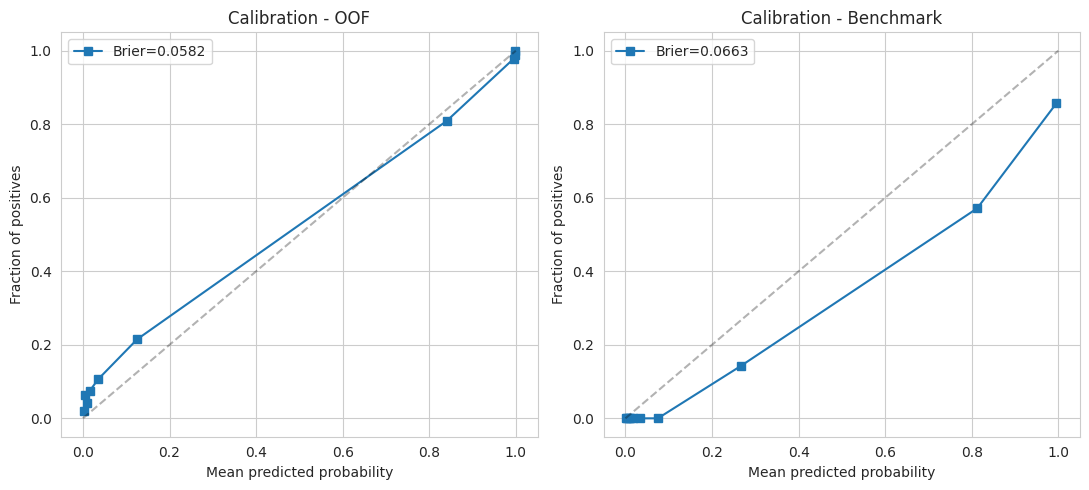

In [11]:
#@title # 12. Calibration curve & Brier score
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, proba, y_true, title in zip(
    axes, [oof_proba, y_bench_proba], [y_train_full, y_bench], ["OOF", "Benchmark"]
):
    frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "s-", label=f"Brier={brier_score_loss(y_true, proba):.4f}")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Calibration - {title}")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "calibration_curves.png"), dpi=600)
plt.show()


False Positives: 8
                                   sequence  pred_proba  seq_len
MTLTSTLRRQTRTTATATVLAAAAALALCAAPASAQQTGP...    0.999099      293
MHLPRSRWDIPFKEETTMTHHFSVRALLAAGALLASAAVS...    0.995831      304
MTASTTRQRISARRLGLRRATLGVATAGLVAAMFTAASAQ...    0.623528      269
MFQRVWALTAALMLMLSLGATSSHAAQNPHERGPDPSNSY...    0.912477      284
MKRRLIAYSIAALAISATAVALPTGVASAAPCSDVDVSFA...    0.935755      216
MGLAIAAAAVFSLPGVATATEPTGGVQPNIVGGGNATQVY...    0.988366      241
MFLLALVTSLIGTGMFTTPVHAAGQFIRDTAPDGRVYKLY...    0.829448      322
MSTASQTYSPWDIRATAGLSPVATCLILIAMGPSCAKILS...    0.913007      428

False Negatives: 3
                                   sequence  pred_proba  seq_len
MLIRPVTFRNMNQQIIGILHTPDNIRLNEKVPGILMFHGF...    0.333135      272
MVRVFGLTLLALLVPALAAPVPEDLEARQSGCADVMVVYA...    0.322855      203
MPPHAARPGPAQNRRGRAMAVITPRRERSSLLSRALRFTA...    0.548417      319


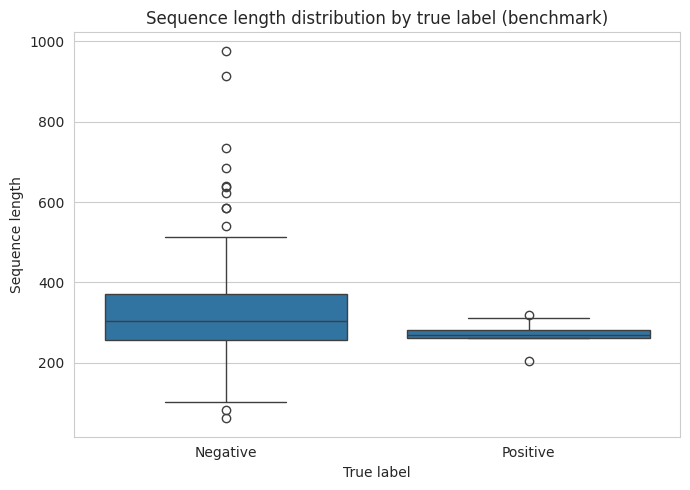

In [12]:
#@title # 13. Error analysis on the benchmark set
df_bench_result = df_bench.copy().reset_index(drop=True)
df_bench_result["pred_proba"] = y_bench_proba
df_bench_result["pred_label"] = y_bench_pred
df_bench_result["seq_len"] = df_bench_result["sequence"].str.len()

false_pos = df_bench_result[(df_bench_result["label"] == 0) & (df_bench_result["pred_label"] == 1)]
false_neg = df_bench_result[(df_bench_result["label"] == 1) & (df_bench_result["pred_label"] == 0)]

print(f"False Positives: {len(false_pos)}")
print(false_pos[["sequence", "pred_proba", "seq_len"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

print(f"\nFalse Negatives: {len(false_neg)}")
print(false_neg[["sequence", "pred_proba", "seq_len"]].assign(
    sequence=lambda d: d["sequence"].str[:40] + "..."
).to_string(index=False))

df_bench_result.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_predictions_detailed.csv"), index=False)

plt.figure(figsize=(7, 5))
sns.boxplot(x="label", y="seq_len", data=df_bench_result)
plt.xticks([0, 1], ["Negative", "Positive"])
plt.xlabel("True label")
plt.ylabel("Sequence length")
plt.title("Sequence length distribution by true label (benchmark)")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "seq_len_by_label.png"), dpi=600)
plt.show()


In [13]:
#@title # 14. Bootstrap confidence intervals for benchmark metrics
# The benchmark set is small (n=139), so point estimates alone can be
# misleading. Bootstrap resampling gives a 95% CI for each metric.

def bootstrap_metric(y_true, values, metric_fn, n_boot=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(metric_fn(y_true[idx], values[idx]))
    return np.mean(scores), np.percentile(scores, [2.5, 97.5])

metrics_to_bootstrap = {
    "f1": (f1_score, y_bench_pred),
    "precision": (precision_score, y_bench_pred),
    "recall": (recall_score, y_bench_pred),
    "auc": (roc_auc_score, y_bench_proba),
    "pr_auc": (average_precision_score, y_bench_proba),
}

print("Benchmark metrics with 95% bootstrap CI (n_boot=2000):")
ci_results = {}
for name, (fn, vals) in metrics_to_bootstrap.items():
    mean, (lo, hi) = bootstrap_metric(y_bench, vals, fn)
    ci_results[name] = {"mean": mean, "ci_low": lo, "ci_high": hi}
    print(f"  {name:<10}: {mean:.4f}  [{lo:.4f}, {hi:.4f}]")

pd.DataFrame(ci_results).T.to_csv(os.path.join(MODEL_OUT_DIR, "benchmark_metrics_bootstrap_ci.csv"))


Benchmark metrics with 95% bootstrap CI (n_boot=2000):
  f1        : 0.7738  [0.6316, 0.8966]
  precision : 0.7061  [0.5332, 0.8750]
  recall    : 0.8651  [0.7059, 1.0000]
  auc       : 0.9659  [0.9348, 0.9901]
  pr_auc    : 0.7908  [0.5891, 0.9526]


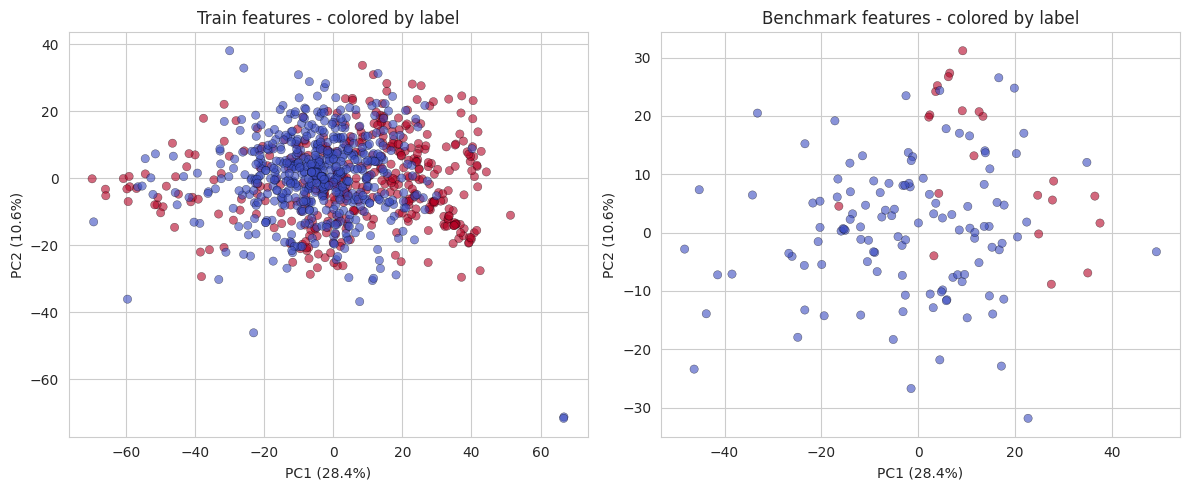

In [14]:
#@title # 15. PCA visualization of AAC/CTD features
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_full)
X_bench_pca = pca.transform(X_bench)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X_pca, y, title in zip(axes, [X_train_pca, X_bench_pca], [y_train_full, y_bench], ["Train", "Benchmark"]):
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.6, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"{title} features - colored by label")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "embedding_pca.png"), dpi=600)
plt.show()


shap_values_pos shape: (937, 167)


/tmp/ipykernel_1577/3935779879.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_pos, X_train_full, feature_names=FEATURE_NAMES, show=False, max_display=20)


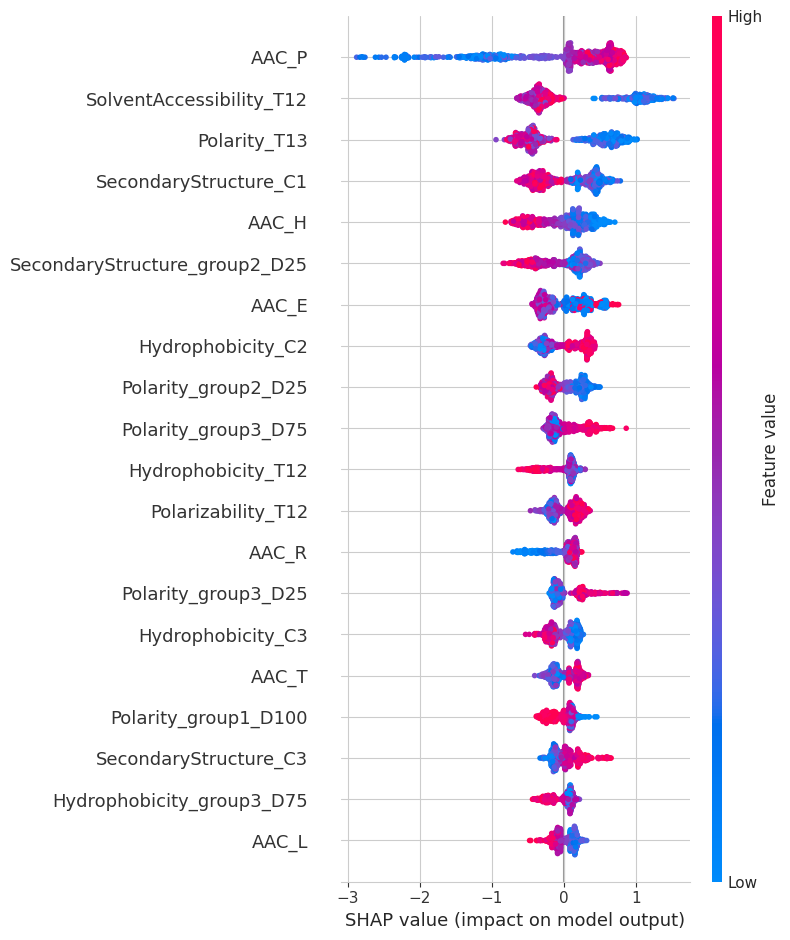

                      feature  mean_abs_shap  xgb_gain_importance
                        AAC_P       0.637115             0.014309
     SolventAccessibility_T12       0.565702             0.020879
                 Polarity_T13       0.544571             0.199629
        SecondaryStructure_C1       0.364524             0.014576
                        AAC_H       0.301493             0.005596
SecondaryStructure_group2_D25       0.286263             0.003031
                        AAC_E       0.275761             0.007790
            Hydrophobicity_C2       0.271717             0.057183
          Polarity_group2_D25       0.198429             0.007475
          Polarity_group3_D75       0.198423             0.007738
           Hydrophobicity_T12       0.172081             0.002319
           Polarizability_T12       0.169454             0.003839
                        AAC_R       0.165130             0.004284
          Polarity_group3_D25       0.162464             0.015315
          

In [15]:
#@title # 16. SHAP analysis - feature-level (direct biological interpretation)
# UNLIKE Model #1-4: AAC/CTD features are human-interpretable by
# construction (e.g. "% charged residues", "% buried hydrophobic
# residues", "position where 50% of polar residues have appeared"), so
# this SHAP analysis is not just a model diagnostic -- it DIRECTLY answers
# which physicochemical properties drive the prediction, without needing
# a separate mutagenesis step to get biological meaning (mutagenesis is
# still run in the next cell for position-level resolution and for
# cross-model comparison).

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train_full)

# XGBoost binary classifiers normally return a single 2D array
# (n_samples, n_features) of SHAP values for the positive class. Some
# library versions / model types can still return a list or a 3D array,
# so we handle those cases defensively too.
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_pos = shap_values[:, :, 1]
else:
    shap_values_pos = shap_values

print(f"shap_values_pos shape: {shap_values_pos.shape}")
assert shap_values_pos.ndim == 2, "shap_values_pos must be 2D (n_samples, n_features)"

plt.figure()
shap.summary_plot(shap_values_pos, X_train_full, feature_names=FEATURE_NAMES, show=False, max_display=20)
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "shap_summary_features.png"), dpi=600, bbox_inches="tight")
plt.show()

mean_abs_shap = np.abs(shap_values_pos).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:20]

importance_df = pd.DataFrame({
    "feature": [FEATURE_NAMES[i] for i in top_idx],
    "mean_abs_shap": mean_abs_shap[top_idx],
    "xgb_gain_importance": final_model.feature_importances_[top_idx],
})
print(importance_df.to_string(index=False))
importance_df.to_csv(os.path.join(MODEL_OUT_DIR, "shap_top_features.csv"), index=False)


Fetching IsPETase (A0A0K8P6T7) from UniProt...
  Length: 290 aa
  Base predicted probability: 0.9993
  Known catalytic triad: [160, 206, 237]
    position 160: rank 188/290 (top 64.8%), delta=-0.00004
    position 206: rank 150/290 (top 51.7%), delta=-0.00002
    position 237: rank 54/290 (top 18.6%), delta=0.00002
  Top-15 predicted important positions: [26, 29, 32, 39, 51, 55, 56, 63, 67, 69, 70, 72, 117, 210, 290]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_ispetase_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_ispetase_full_scan.csv

  Alanine substitution vs full residue deletion (catalytic triad only):
 position residue  alanine_delta  deletion_delta
      160       S      -0.000036       -0.000050
      206       D      -0.000024       -0.000048
      237       H     

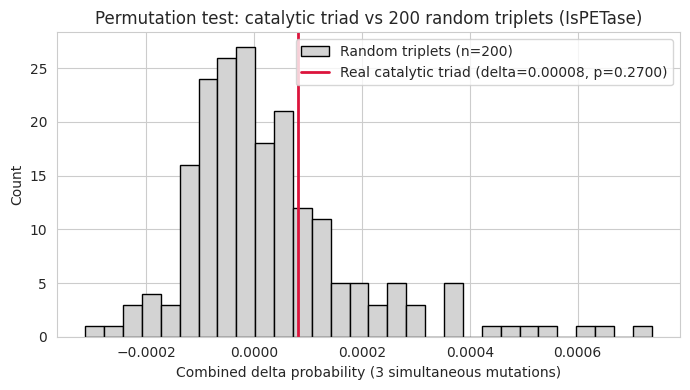


  Running windowed mutagenesis scan (window_size=7)... AAC/CTD features are cheap to recompute directly from the sequence string, so this is fast even for long sequences.
  Window-centered rank of catalytic positions (window_size=7):
    position 160: window-rank 255/290 (top 87.9%), window_delta=-0.00004 (vs single-residue delta=-0.00004)
    position 206: window-rank 198/290 (top 68.3%), window_delta=0.00009 (vs single-residue delta=-0.00002)
    position 237: window-rank 243/290 (top 83.8%), window_delta=-0.00001 (vs single-residue delta=0.00002)


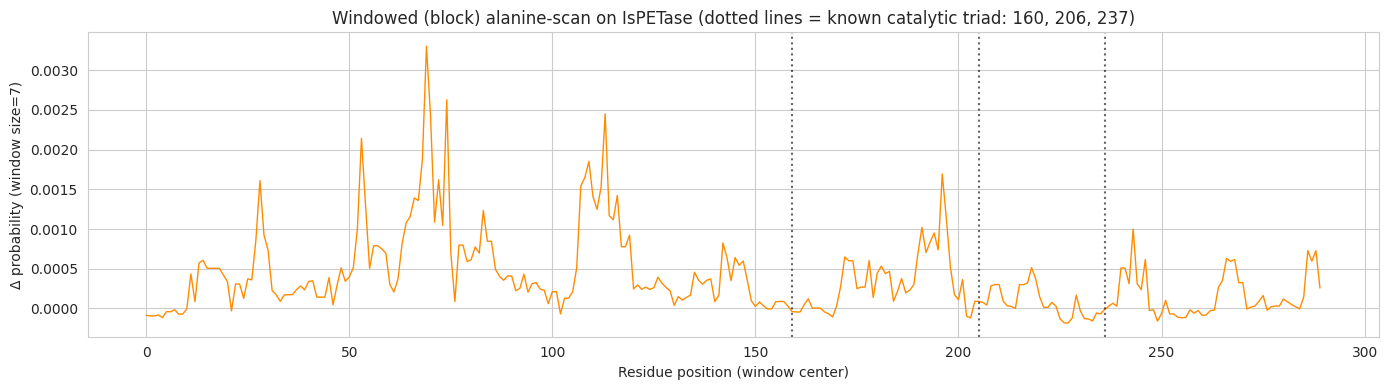

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_ispetase_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_ispetase_windowed_scan.csv


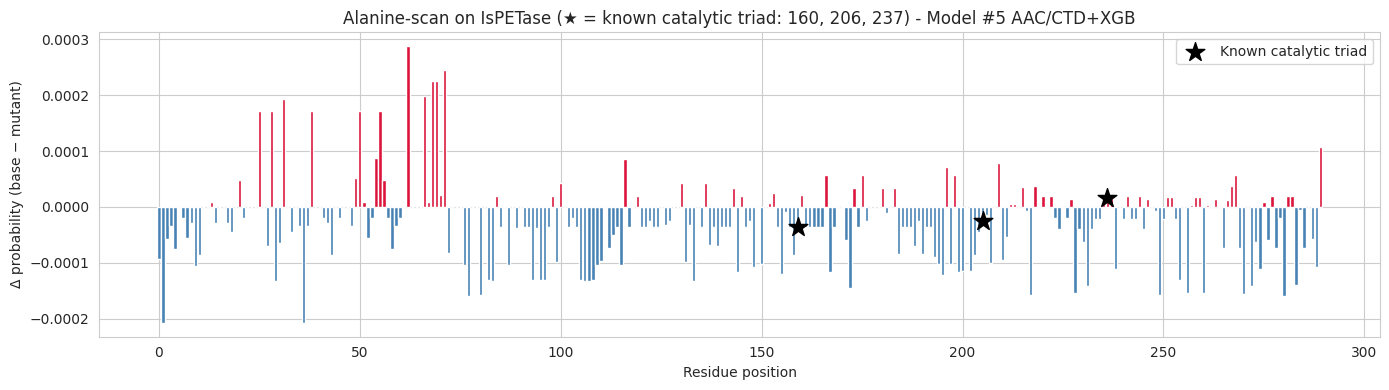

Fetching LCC (G9BY57) from UniProt...
  Length: 293 aa
  Base predicted probability: 0.9990
  Known catalytic triad: [165, 210, 242]
    position 165: rank 225/293 (top 76.8%), delta=0.00000
    position 210: rank 81/293 (top 27.6%), delta=0.00016
    position 242: rank 57/293 (top 19.5%), delta=0.00019
  Top-15 predicted important positions: [80, 82, 120, 121, 122, 127, 141, 158, 189, 198, 201, 275, 290, 291, 292]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_lcc_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_lcc_full_scan.csv

  Alanine substitution vs full residue deletion (catalytic triad only):
 position residue  alanine_delta  deletion_delta
      165       S       0.000000        0.000562
      210       D       0.000159        0.000460
      242       H       0.000195  

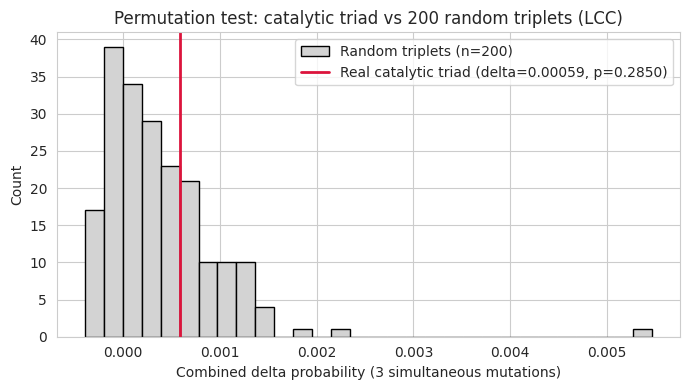


  Running windowed mutagenesis scan (window_size=7)... AAC/CTD features are cheap to recompute directly from the sequence string, so this is fast even for long sequences.
  Window-centered rank of catalytic positions (window_size=7):
    position 165: window-rank 231/293 (top 78.8%), window_delta=0.00078 (vs single-residue delta=0.00000)
    position 210: window-rank 232/293 (top 79.2%), window_delta=0.00075 (vs single-residue delta=0.00016)
    position 242: window-rank 204/293 (top 69.6%), window_delta=0.00095 (vs single-residue delta=0.00019)


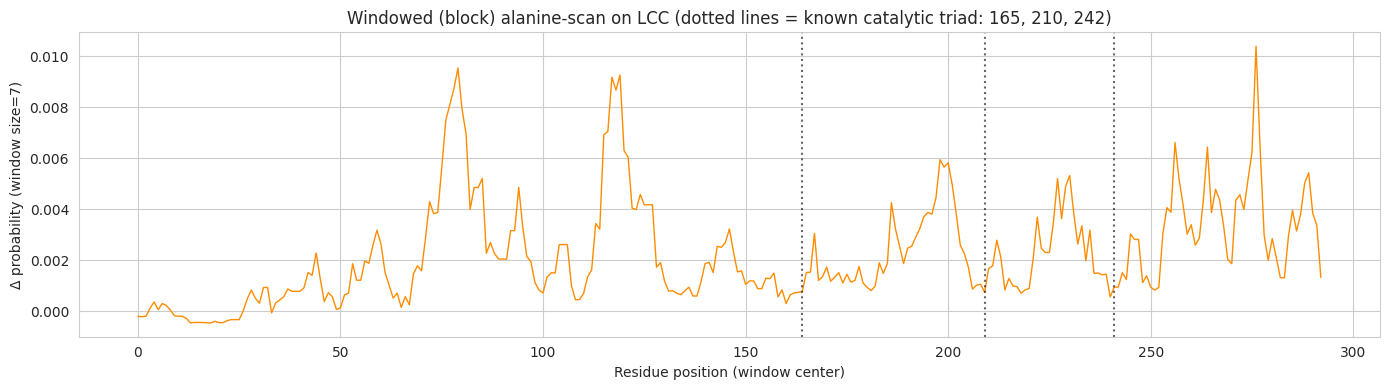

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_lcc_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_lcc_windowed_scan.csv


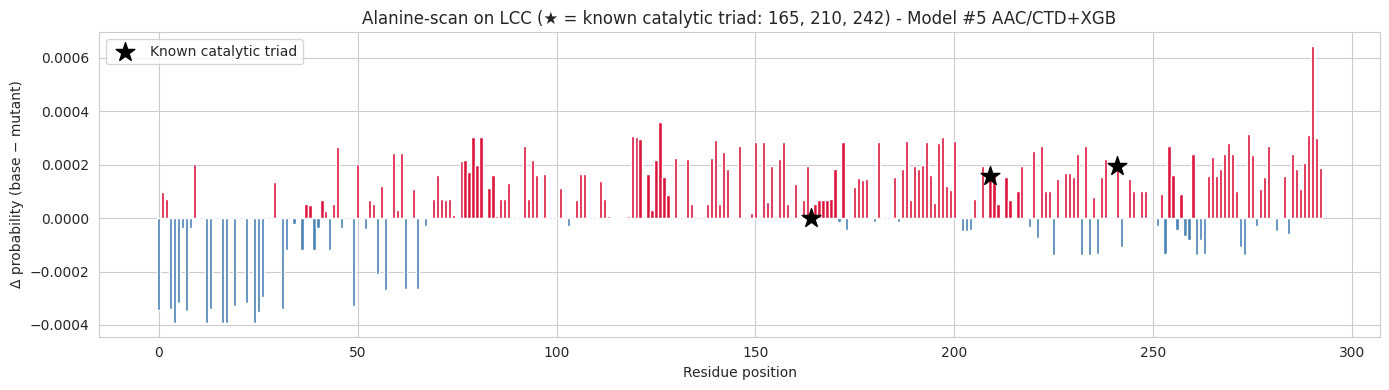

Fetching CalB_negative_control (P41365) from UniProt...
  Length: 342 aa
  Base predicted probability: 0.9905
  Known catalytic triad: [130, 212, 249]
    position 130: rank 163/342 (top 47.7%), delta=0.00161
    position 212: rank 159/342 (top 46.5%), delta=0.00165
    position 249: rank 105/342 (top 30.7%), delta=0.00322
  Top-15 predicted important positions: [193, 263, 267, 274, 278, 283, 284, 289, 294, 295, 315, 316, 317, 327, 334]
  Overlap with catalytic triad (top-15): [] (0/3)
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_calb_negative_control_full_scan.xlsx
  Saved full per-residue delta table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_calb_negative_control_full_scan.csv

  Alanine substitution vs full residue deletion (catalytic triad only):
 position residue  alanine_delta  deletion_delta
      130       S       0.001606        0.004031
      212       D       0

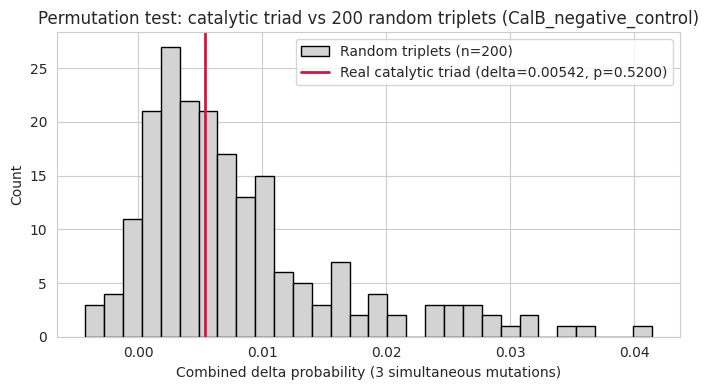


  Running windowed mutagenesis scan (window_size=7)... AAC/CTD features are cheap to recompute directly from the sequence string, so this is fast even for long sequences.
  Window-centered rank of catalytic positions (window_size=7):
    position 130: window-rank 254/342 (top 74.3%), window_delta=0.00177 (vs single-residue delta=0.00161)
    position 212: window-rank 140/342 (top 40.9%), window_delta=0.01819 (vs single-residue delta=0.00165)
    position 249: window-rank 114/342 (top 33.3%), window_delta=0.02527 (vs single-residue delta=0.00322)


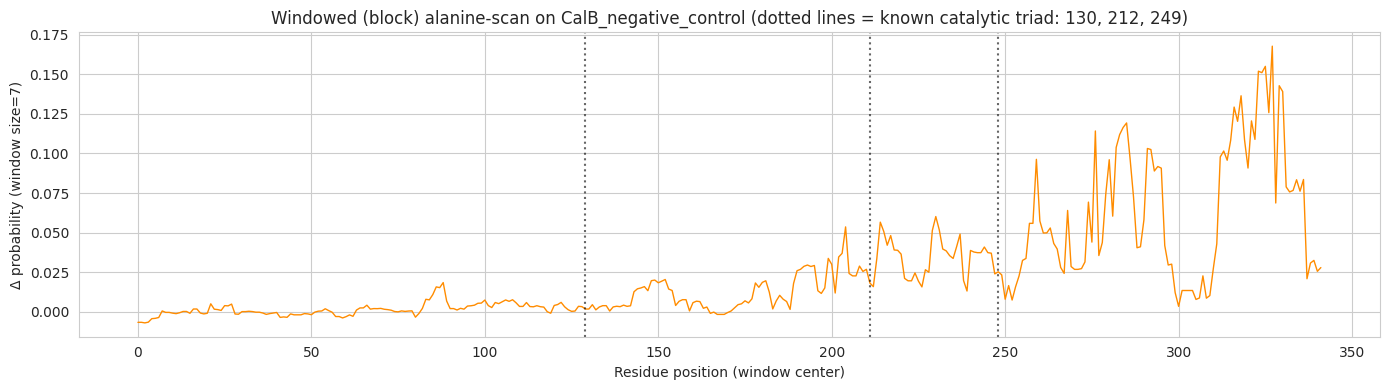

  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_calb_negative_control_windowed_scan.xlsx
  Saved windowed scan table to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_calb_negative_control_windowed_scan.csv


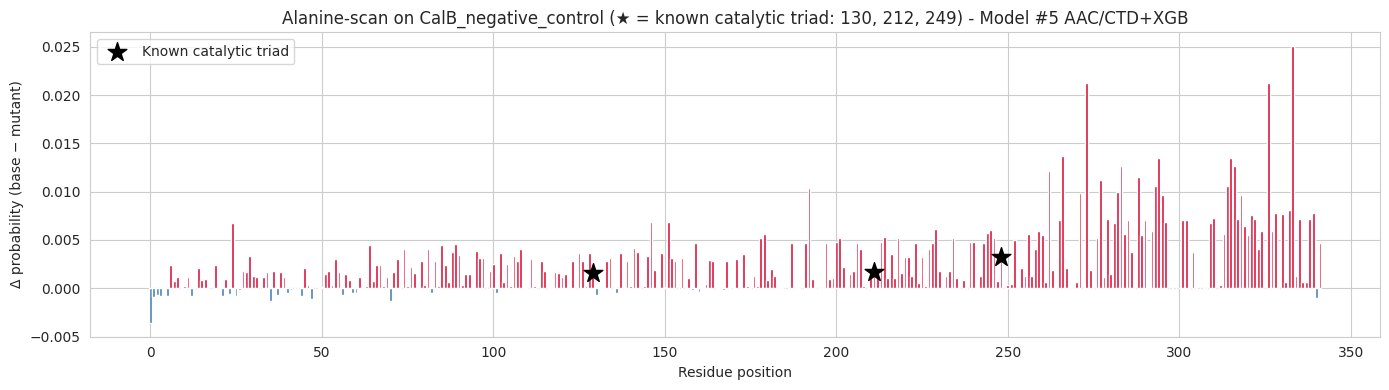


Saved reference scan results to /content/drive/MyDrive/InterPET/models/model5_aac_ctd_xgb/reference_mutagenesis_results.pkl


In [7]:
#@title # 17. Fixed reference-sequence scan -- IsPETase active site (valid cross-model comparison)
# This section replaces the old "highest-confidence TP" demo (which picked a
# different, model-dependent sequence every time and was not usable for
# cross-model comparison). Instead we scan a FIXED reference sequence, chosen
# independently of any model's predictions, with a catalytic site already
# confirmed in the literature: IsPETase (Ideonella sakaiensis PETase),
# UniProt A0A0K8P6T7.
#
#   Catalytic triad: Ser160, Asp206, His237
#   (Yoshida et al. 2016, Science; Han et al. 2017, Nat. Commun., PDB 5XJH --
#   confirmed structurally and by site-directed mutagenesis; any substitution
#   at these positions abolishes catalytic activity.)
#
# Because every model notebook scans this exact same sequence, the top
# residues each model highlights can be directly compared, and checked
# against a real, experimentally-confirmed active site -- not just against
# each other.
#
# Unlike Model #1-4, no protein language model call is needed here -- AAC/
# CTD features are recomputed directly from the sequence string, so this
# scan is essentially instant even for long sequences and many positions.

!pip install -q openpyxl
import requests


def get_features_single(sequence):
    return compute_features(sequence)


def mutagenesis_scan(sequence, model, mutate_to="A"):
    """Return (base_proba, per_position_deltas) for a single sequence.
    delta[i] = base_proba - proba_after_mutating_position_i_to_`mutate_to`.
    A positive delta means residue i supports the positive-class prediction."""
    seq = sequence.strip().upper()
    base_feat = get_features_single(seq).reshape(1, -1)
    base_proba = model.predict_proba(base_feat)[0, 1]

    deltas = np.zeros(len(seq))
    for i, aa in enumerate(seq):
        if aa == mutate_to:
            deltas[i] = 0.0
            continue
        mutant_seq = seq[:i] + mutate_to + seq[i + 1:]
        mutant_feat = get_features_single(mutant_seq).reshape(1, -1)
        mutant_proba = model.predict_proba(mutant_feat)[0, 1]
        deltas[i] = base_proba - mutant_proba

    return base_proba, deltas


def windowed_mutagenesis_scan(sequence, model, window_size=7, mutate_to="A"):
    """Slide a contiguous window across the sequence, mutating the WHOLE
    window to alanine at once (rather than one residue at a time), and
    record the resulting delta at the window's center position.
    This can reveal regions that matter collectively even when no single
    residue inside them stands out on its own (i.e. individual mutations
    are below the mean-pooling noise floor, but a whole disrupted block
    is not)."""
    seq = sequence.strip().upper()
    n = len(seq)
    half = window_size // 2

    base_feat = get_features_single(seq).reshape(1, -1)
    base_proba = model.predict_proba(base_feat)[0, 1]

    window_deltas = np.zeros(n)
    for center in range(n):
        start = max(0, center - half)
        end = min(n, center + half + 1)
        mutant_seq = seq[:start] + mutate_to * (end - start) + seq[end:]
        mutant_feat = get_features_single(mutant_seq).reshape(1, -1)
        mutant_proba = model.predict_proba(mutant_feat)[0, 1]
        window_deltas[center] = base_proba - mutant_proba

    return base_proba, window_deltas


REFERENCE_SEQUENCES = {
    "IsPETase": {
        "uniprot_id": "A0A0K8P6T7",
        "source": "Yoshida et al. 2016 Science; Han et al. 2017 Nat Commun (PDB 5XJH)",
        "catalytic_triad_positions": [160, 206, 237],  # Ser160, Asp206, His237 (1-indexed)
        "expected_residues": {160: "S", 206: "D", 237: "H"},
        "is_petase": True,
    },
    "LCC": {
        "uniprot_id": "G9BY57",
        "source": "Sulaiman et al. 2012 Appl Environ Microbiol; Tournier et al. 2020 Nature (PDB 4EB0)",
        "catalytic_triad_positions": [165, 210, 242],  # Ser165, Asp210, His242 (1-indexed)
        "expected_residues": {165: "S", 210: "D", 242: "H"},
        "is_petase": True,
    },
    "CalB_negative_control": {
        "uniprot_id": "P41365",
        "source": "Uppenberg et al. 1994 Structure (PDB 1TCA) -- Candida antarctica Lipase B, "
                   "NOT PET-active; same catalytic mechanism/fold family as PETases, used as "
                   "a functional-specificity negative control",
        "catalytic_triad_positions": [130, 212, 249],  # Ser130, Asp212, His249 (1-indexed)
        "expected_residues": {130: "S", 212: "D", 249: "H"},
        "is_petase": False,
    },
}


def fetch_uniprot_sequence(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    lines = resp.text.strip().split("\n")
    return "".join(lines[1:])  # drop the ">header" line


reference_scan_results = {}

for ref_name, ref_info in REFERENCE_SEQUENCES.items():
    print(f"Fetching {ref_name} ({ref_info['uniprot_id']}) from UniProt...")
    ref_seq = fetch_uniprot_sequence(ref_info["uniprot_id"])
    print(f"  Length: {len(ref_seq)} aa")

    base_p, deltas = mutagenesis_scan(ref_seq, final_model)
    print(f"  Base predicted probability: {base_p:.4f}")

    top_n = 15
    order = np.argsort(deltas)[::-1]
    top_positions = set((order[:top_n] + 1).tolist())  # 1-indexed
    known_positions = set(ref_info["catalytic_triad_positions"])
    overlap = known_positions & top_positions

    rank_of = {pos: int(np.where(order == (pos - 1))[0][0]) + 1 for pos in known_positions}
    n_total = len(deltas)
    print(f"  Known catalytic triad: {sorted(known_positions)}")
    for pos in sorted(known_positions):
        pct_from_top = 100 * rank_of[pos] / n_total
        print(f"    position {pos}: rank {rank_of[pos]}/{n_total} (top {pct_from_top:.1f}%), delta={deltas[pos-1]:.5f}")
    print(f"  Top-{top_n} predicted important positions: {sorted(top_positions)}")
    print(f"  Overlap with catalytic triad (top-{top_n}): {sorted(overlap)} ({len(overlap)}/{len(known_positions)})")

    # ---- Export full per-residue delta table to Excel + CSV ----
    full_scan_df = pd.DataFrame({
        "position": np.arange(1, len(ref_seq) + 1),
        "residue": list(ref_seq),
        "delta_proba": deltas,
        "is_known_catalytic_residue": [p in known_positions for p in range(1, len(ref_seq) + 1)],
    }).sort_values("delta_proba", ascending=False).reset_index(drop=True)

    excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.xlsx")
    csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_full_scan.csv")
    full_scan_df.to_excel(excel_path, index=False, sheet_name="alanine_scan")
    full_scan_df.to_csv(csv_path, index=False)
    print(f"  Saved full per-residue delta table to {excel_path}")
    print(f"  Saved full per-residue delta table to {csv_path}")

    # ---- Variation 1: residue DELETION vs alanine substitution, at the 3 known positions only ----
    # ESM-2/ProtT5 notebooks compare alanine substitution against a language-
    # model-specific "masked/unknown residue" token. AAC/CTD features have no
    # such token -- but because they are computed directly from the sequence
    # string, we can cleanly probe a perturbation embedding models can't:
    # fully DELETING the residue (shortening the sequence by one) instead of
    # replacing it with alanine. This tests whether a residue's importance
    # comes from WHICH amino acid sits at that position (captured by alanine
    # substitution) or merely from its presence in the composition/length
    # statistics (captured by deletion).
    deletion_comparison = []
    for pos in sorted(known_positions):
        deleted_seq = ref_seq[:pos - 1] + ref_seq[pos:]
        del_feat = get_features_single(deleted_seq).reshape(1, -1)
        del_proba = final_model.predict_proba(del_feat)[0, 1]
        del_delta = base_p - del_proba
        deletion_comparison.append({
            "position": pos,
            "residue": ref_seq[pos - 1],
            "alanine_delta": deltas[pos - 1],
            "deletion_delta": del_delta,
        })

    deletion_comparison_df = pd.DataFrame(deletion_comparison)
    print("\n  Alanine substitution vs full residue deletion (catalytic triad only):")
    print(deletion_comparison_df.to_string(index=False))

    # ---- Variation 2: combined (simultaneous) triple mutation vs sum of individual deltas ----
    seq_list = list(ref_seq)
    for pos in known_positions:
        seq_list[pos - 1] = "A"
    combined_mutant_seq = "".join(seq_list)
    combined_feat = get_features_single(combined_mutant_seq).reshape(1, -1)
    combined_proba = final_model.predict_proba(combined_feat)[0, 1]
    combined_delta = base_p - combined_proba
    sum_individual_deltas = sum(deltas[pos - 1] for pos in known_positions)

    print(f"\n  Combined triple-mutation (all 3 catalytic residues -> Ala simultaneously):")
    print(f"    proba after combined mutation : {combined_proba:.4f}")
    print(f"    combined delta                : {combined_delta:.5f}")
    print(f"    sum of individual deltas       : {sum_individual_deltas:.5f}")
    print(f"    synergy (combined - sum)        : {combined_delta - sum_individual_deltas:.5f}")

    # ---- Variation 2b: permutation test for the combined-mutation synergy ----
    # Is the combined delta actually special, or would mutating ANY random
    # triplet of positions simultaneously tend to produce a similarly large
    # delta (since disturbing 3 positions at once is inherently a bigger
    # perturbation than disturbing 1)? We build a null distribution from
    # random triplets (excluding the real triad) and see where the real
    # triad's combined delta falls within it.
    n_permutations = 200
    rng = np.random.default_rng(RANDOM_SEED)
    all_positions = np.arange(1, len(ref_seq) + 1)
    candidate_positions = np.setdiff1d(all_positions, list(known_positions))

    null_deltas = np.zeros(n_permutations)
    for p_i in range(n_permutations):
        rand_positions = rng.choice(candidate_positions, size=len(known_positions), replace=False)
        seq_list_rand = list(ref_seq)
        for pos in rand_positions:
            seq_list_rand[pos - 1] = "A"
        rand_mutant_seq = "".join(seq_list_rand)
        rand_feat = get_features_single(rand_mutant_seq).reshape(1, -1)
        rand_proba = final_model.predict_proba(rand_feat)[0, 1]
        null_deltas[p_i] = base_p - rand_proba
        if (p_i + 1) % 50 == 0:
            print(f"    permutation {p_i + 1}/{n_permutations}...")

    p_value = float(np.mean(null_deltas >= combined_delta))
    z_score = float((combined_delta - null_deltas.mean()) / (null_deltas.std() + 1e-12))

    print(f"\n  Permutation test (n={n_permutations} random triplets of positions, "
          f"excluding the real catalytic triad):")
    print(f"    null distribution -- mean={null_deltas.mean():.5f}, std={null_deltas.std():.5f}, "
          f"max={null_deltas.max():.5f}")
    print(f"    observed combined delta (real catalytic triad): {combined_delta:.5f}")
    print(f"    empirical p-value (P[null >= observed]): {p_value:.4f}")
    print(f"    z-score: {z_score:.3f}")

    plt.figure(figsize=(7, 4))
    plt.hist(null_deltas, bins=30, color="lightgray", edgecolor="black", label=f"Random triplets (n={n_permutations})")
    plt.axvline(combined_delta, color="crimson", linewidth=2,
                label=f"Real catalytic triad (delta={combined_delta:.5f}, p={p_value:.4f})")
    plt.xlabel("Combined delta probability (3 simultaneous mutations)")
    plt.ylabel("Count")
    plt.title(f"Permutation test: catalytic triad vs {n_permutations} random triplets ({ref_name})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_test.png"), dpi=600)
    plt.show()

    pd.DataFrame({"null_delta": null_deltas}).to_csv(
        os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_permutation_null.csv"), index=False
    )

    # ---- Variation 3: windowed/block mutagenesis ----
    window_size = 7
    print(f"\n  Running windowed mutagenesis scan (window_size={window_size})... AAC/CTD features are cheap to recompute directly from the sequence string, so this is fast even for long sequences.")
    _, window_deltas = windowed_mutagenesis_scan(ref_seq, final_model, window_size=window_size)

    window_order = np.argsort(window_deltas)[::-1]
    print(f"  Window-centered rank of catalytic positions (window_size={window_size}):")
    for pos in sorted(known_positions):
        w_rank = int(np.where(window_order == (pos - 1))[0][0]) + 1
        w_pct = 100 * w_rank / n_total
        print(f"    position {pos}: window-rank {w_rank}/{n_total} (top {w_pct:.1f}%), "
              f"window_delta={window_deltas[pos-1]:.5f} (vs single-residue delta={deltas[pos-1]:.5f})")

    plt.figure(figsize=(14, 4))
    plt.plot(range(len(window_deltas)), window_deltas, color="darkorange", linewidth=1)
    for pos in known_positions:
        plt.axvline(pos - 1, color="black", linestyle=":", alpha=0.6)
    plt.xlabel("Residue position (window center)")
    plt.ylabel(f"Δ probability (window size={window_size})")
    plt.title(f"Windowed (block) alanine-scan on {ref_name} "
              f"(dotted lines = known catalytic triad: {', '.join(str(p) for p in sorted(known_positions))})")
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed.png"), dpi=600)
    plt.show()

    window_scan_df = pd.DataFrame({
        "position": np.arange(1, len(ref_seq) + 1),
        "residue": list(ref_seq),
        "window_delta_proba": window_deltas,
        "single_residue_delta_proba": deltas,
        "is_known_catalytic_residue": [p in known_positions for p in range(1, len(ref_seq) + 1)],
    }).sort_values("window_delta_proba", ascending=False).reset_index(drop=True)
    window_excel_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.xlsx")
    window_csv_path = os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}_windowed_scan.csv")
    window_scan_df.to_excel(window_excel_path, index=False, sheet_name=f"window{window_size}_scan")
    window_scan_df.to_csv(window_csv_path, index=False)
    print(f"  Saved windowed scan table to {window_excel_path}")
    print(f"  Saved windowed scan table to {window_csv_path}")

    reference_scan_results[ref_name] = {
        "sequence": ref_seq,
        "base_proba": base_p,
        "deltas": deltas,
        "window_deltas": window_deltas,
        "window_size": window_size,
        "top_positions": sorted(top_positions),
        "known_catalytic_triad": sorted(known_positions),
        "overlap_with_catalytic_triad": sorted(overlap),
        "rank_of_known_positions": rank_of,
        "deletion_vs_alanine_comparison": deletion_comparison,
        "combined_triple_mutation_delta": combined_delta,
        "sum_of_individual_deltas": sum_individual_deltas,
        "permutation_test_null_deltas": null_deltas,
        "permutation_test_p_value": p_value,
        "permutation_test_z_score": z_score,
    }

    plt.figure(figsize=(14, 4))
    colors = ["crimson" if d > 0 else "steelblue" for d in deltas]
    plt.bar(range(len(deltas)), deltas, color=colors)
    for pos in known_positions:
        plt.scatter([pos - 1], [deltas[pos - 1]], marker="*", s=200,
                    color="black", zorder=5,
                    label="Known catalytic triad" if pos == min(known_positions) else None)
    plt.xlabel("Residue position")
    plt.ylabel("Δ probability (base − mutant)")
    plt.title(f"Alanine-scan on {ref_name} (★ = known catalytic triad: "
              f"{', '.join(str(p) for p in sorted(known_positions))}) - Model #5 AAC/CTD+XGB")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_OUT_DIR, f"reference_mutagenesis_{ref_name.lower()}.png"), dpi=600)
    plt.show()

with open(os.path.join(MODEL_OUT_DIR, "reference_mutagenesis_results.pkl"), "wb") as f:
    pickle.dump(reference_scan_results, f)

print(f"\nSaved reference scan results to {MODEL_OUT_DIR}/reference_mutagenesis_results.pkl")


In [ ]:
#@title # 18. Top-15 residues for the top-3 highest-confidence benchmark sequences
# Selection criterion here is purely the model's own predicted probability
# (base_proba on the benchmark set) -- the 3 sequences the model is most
# confident about, regardless of TP/FP/FN status. mutagenesis_scan() was
# already defined in the previous section, so it's reused as-is here
# (AAC/CTD feature recomputation instead of a language-model embedding call, otherwise identical).

top3_rows = np.argsort(y_bench_proba)[::-1][:3]
print(f"Top-3 benchmark rows by base_proba: {list(top3_rows)}")

excel_path = os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.xlsx")
top15_summary = []

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for row in top3_rows:
        seq = df_bench.iloc[row]["sequence"]
        base_p, deltas = mutagenesis_scan(seq, final_model)

        top15_idx = np.argsort(deltas)[::-1][:15]
        row_df = pd.DataFrame({
            "position": top15_idx + 1,  # 1-indexed
            "residue": [seq[i] for i in top15_idx],
            "delta_proba": deltas[top15_idx],
        })
        row_df.insert(0, "benchmark_row", row)
        row_df.insert(1, "base_proba", base_p)

        sheet_name = f"row_{row}"[:31]  # Excel sheet name limit
        row_df.to_excel(writer, index=False, sheet_name=sheet_name)
        top15_summary.append(row_df)

        print(f"\nRow {row} (base_proba={base_p:.4f}) -- top 15 residues:")
        print(row_df[["position", "residue", "delta_proba"]].to_string(index=False))

print(f"\nSaved top-15 tables for top-3 benchmark rows to {excel_path}")

top15_summary_df = pd.concat(top15_summary, ignore_index=True)
top15_summary_df.to_csv(os.path.join(MODEL_OUT_DIR, "batch_mutagenesis_top15_top3rows.csv"), index=False)


Top-3 benchmark rows by base_proba: [np.int64(23), np.int64(8), np.int64(29)]

Row 23 (base_proba=0.9992) -- top 15 residues:
 position residue  delta_proba
      242       C     0.000350
      109       Y     0.000244
       86       T     0.000212
       64       T     0.000188
       89       T     0.000188
       73       Y     0.000188
       91       T     0.000188
      111       T     0.000188
       88       D     0.000153
       85       F     0.000137
      155       P     0.000132
      168       P     0.000132
       94       D     0.000130
       82       F     0.000115
      154       T     0.000112

Row 8 (base_proba=0.9991) -- top 15 residues:
 position residue  delta_proba
      292       P     0.000299
      210       P     0.000273
      197       P     0.000273
      217       P     0.000273
      225       S     0.000273
      241       P     0.000273
      247       P     0.000273
      224       S     0.000273
      236       S     0.000273
      142       S    